# Task 4: Predicting Insurance Claim Amounts

**Organization:** DevelopersHub Corporation  
**Internship:** Data Science & Analytics  
**Author:** Khola Asghar  
**Date:** 23 April 2026  
**Dataset:** Medical Cost Personal Dataset (Kaggle)

---

## 1. Introduction and Problem Statement

Medical insurance companies need to estimate how much a customer 
is likely to claim based on their personal information. This helps 
them set appropriate premium prices and manage financial risk.

The goal of this task is to build a Linear Regression model that 
predicts medical insurance charges based on personal data such as 
age, BMI, smoking status, and number of children.

**Business Question:**
How much will a customer's medical insurance claim be based 
on their personal and lifestyle information?

## 2. Dataset Understanding and Description

The Medical Cost Personal Dataset contains information about 
1,338 insurance customers including their age, gender, BMI, 
number of children, smoking status, region, and medical charges.

The target variable is charges which represents the medical 
insurance cost billed to the customer. This is a regression 
problem because we are predicting a continuous numerical value.

In [2]:

# Importing all required libraries
import pandas as pd                          # For data loading and manipulation
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For creating visualizations
import seaborn as sns                        # For advanced visualizations
from sklearn.linear_model import LinearRegression  # Our main model
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.metrics import mean_absolute_error, mean_squared_error  # For evaluation
from sklearn.preprocessing import LabelEncoder  # For encoding categorical columns

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Cleaning and Preparation

In this section we load the dataset, inspect its structure, 
check for missing values, and encode categorical features 
to prepare the data for model training.

In [3]:
# ================================================
# Loading the Dataset
# ================================================

df = pd.read_csv(r'C:\Users\dell\Downloads\archive (2)\insurance.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
# ================================================
# Dataset Inspection
# Understanding data types and missing values
# ================================================

# Display data types of each column
print("Data Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values in Each Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0

Basic Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [5]:
# ================================================
# Encoding Categorical Columns
# Converting text values to numbers for the model
# sex: female=0, male=1
# smoker: no=0, yes=1
# region: encoded as numbers
# ================================================

le = LabelEncoder()

# Encode categorical columns
df['sex'] = le.fit_transform(df['sex'])          # Encode gender
df['smoker'] = le.fit_transform(df['smoker'])    # Encode smoking status
df['region'] = le.fit_transform(df['region'])    # Encode region

print("Encoding complete!")
print("\nDataset after encoding:")
print(df.head())

Encoding complete!

Dataset after encoding:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


## 4. Exploratory Data Analysis (EDA)

We create visualizations to understand how different features 
such as BMI, age, and smoking status impact insurance charges. 
This helps us identify the most important predictors before 
building our regression model.

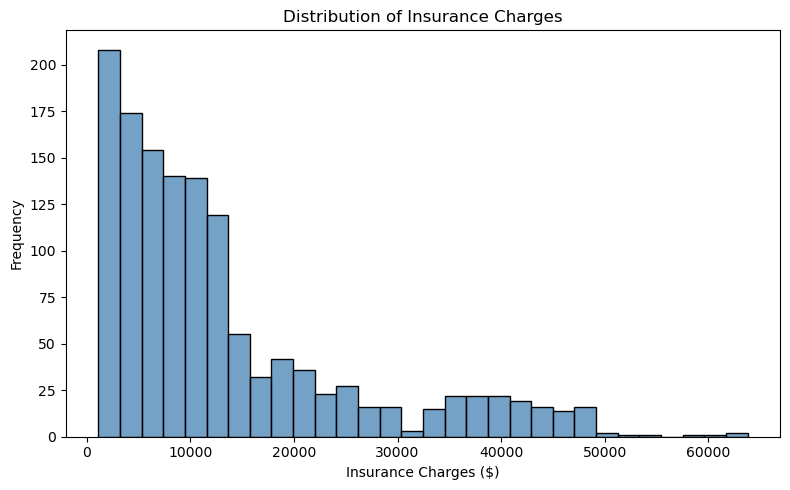

Most customers have lower insurance charges with a few very high claims


In [7]:
# ================================================
# Visualization 1: Insurance Charges Distribution
# Understanding how charges are spread across customers
# ================================================

plt.figure(figsize=(8, 5))

# Create histogram of insurance charges
sns.histplot(df['charges'], bins=30, color='steelblue')

plt.title('Distribution of Insurance Charges')  # Title
plt.xlabel('Insurance Charges ($)')              # X axis label
plt.ylabel('Frequency')                          # Y axis label
plt.tight_layout()
plt.savefig('charges_distribution.png')          # Save the plot
plt.show()

print("Most customers have lower insurance charges with a few very high claims")

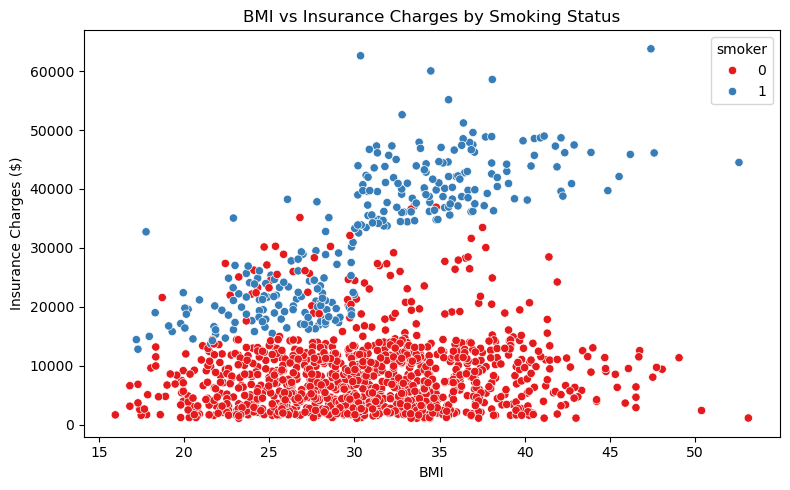

Smokers with high BMI tend to have significantly higher charges


In [8]:
# ================================================
# Visualization 2: BMI vs Insurance Charges
# Checking how body mass index affects charges
# ================================================

plt.figure(figsize=(8, 5))

# Scatter plot of BMI vs charges colored by smoking status
sns.scatterplot(
    data=df,
    x='bmi',                    # X axis: BMI values
    y='charges',                # Y axis: insurance charges
    hue='smoker',               # Color by smoking status
    palette='Set1'              # Color palette
)

plt.title('BMI vs Insurance Charges by Smoking Status')  # Title
plt.xlabel('BMI')                                         # X axis label
plt.ylabel('Insurance Charges ($)')                       # Y axis label
plt.tight_layout()
plt.savefig('bmi_charges.png')                           # Save the plot
plt.show()

print("Smokers with high BMI tend to have significantly higher charges")

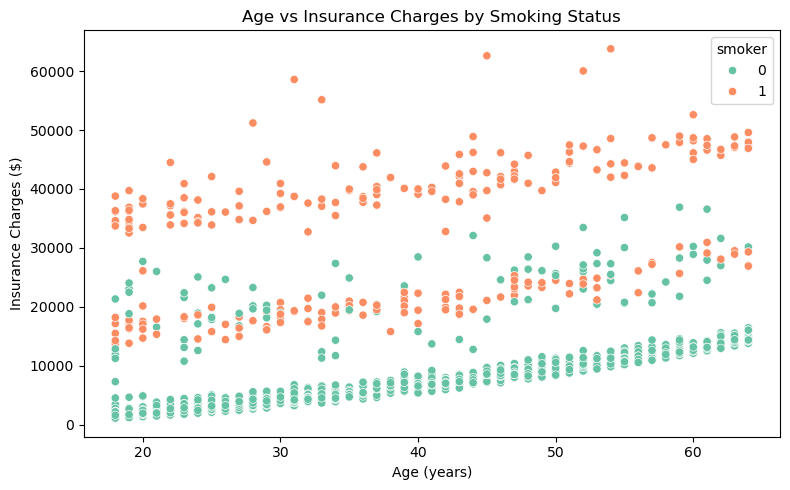

Charges increase with age and smokers pay significantly more


In [9]:
# ================================================
# Visualization 3: Age vs Insurance Charges
# Checking how age affects insurance charges
# ================================================

plt.figure(figsize=(8, 5))

# Scatter plot of age vs charges colored by smoking status
sns.scatterplot(
    data=df,
    x='age',                    # X axis: age values
    y='charges',                # Y axis: insurance charges
    hue='smoker',               # Color by smoking status
    palette='Set2'              # Color palette
)

plt.title('Age vs Insurance Charges by Smoking Status')  # Title
plt.xlabel('Age (years)')                                 # X axis label
plt.ylabel('Insurance Charges ($)')                       # Y axis label
plt.tight_layout()
plt.savefig('age_charges.png')                           # Save the plot
plt.show()

print("Charges increase with age and smokers pay significantly more")

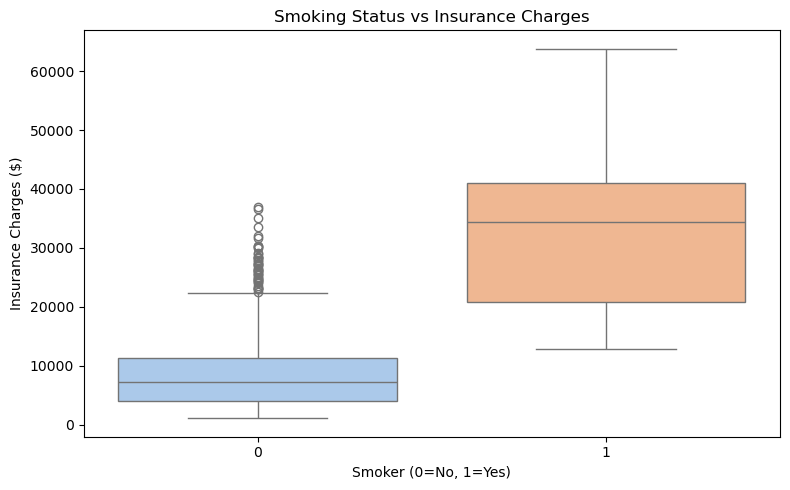

Smokers pay on average 3-4 times more than non-smokers!


In [10]:
# ================================================
# Visualization 4: Smoking Status vs Charges
# Box plot showing impact of smoking on charges
# ================================================

plt.figure(figsize=(8, 5))

# Box plot of smoking status vs charges
sns.boxplot(
    data=df,
    x='smoker',                 # X axis: smoking status
    y='charges',                # Y axis: insurance charges
    hue='smoker',               # Color by smoking status
    palette='pastel',           # Color palette
    legend=False                # Hide legend
)

plt.title('Smoking Status vs Insurance Charges')  # Title
plt.xlabel('Smoker (0=No, 1=Yes)')                # X axis label
plt.ylabel('Insurance Charges ($)')               # Y axis label
plt.tight_layout()
plt.savefig('smoker_charges.png')                 # Save the plot
plt.show()

print("Smokers pay on average 3-4 times more than non-smokers!")

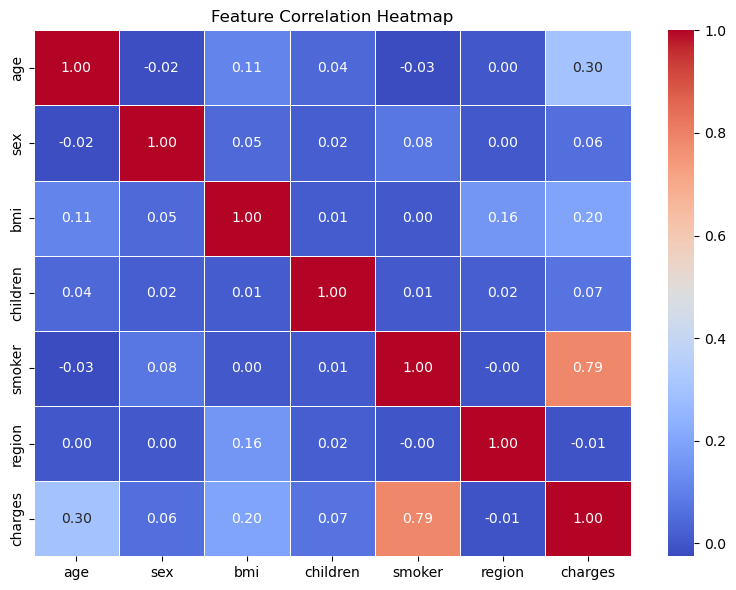

Smoking status has the strongest correlation with insurance charges


In [11]:
# ================================================
# Visualization 5: Correlation Heatmap
# Shows how strongly each feature relates to charges
# ================================================

plt.figure(figsize=(8, 6))

# Calculate correlation matrix
correlation = df.corr()

# Create heatmap
sns.heatmap(
    correlation,
    annot=True,                 # Show numbers in cells
    fmt='.2f',                  # Format to 2 decimal places
    cmap='coolwarm',            # Color scheme
    linewidths=0.5              # Lines between cells
)

plt.title('Feature Correlation Heatmap')  # Title
plt.tight_layout()
plt.savefig('correlation_heatmap.png')    # Save the plot
plt.show()

print("Smoking status has the strongest correlation with insurance charges")

## 5. Model Training and Testing

We prepare the features and target variable, split the data 
into training and testing sets, and train a Linear Regression 
model to predict insurance charges.

In [12]:
# ================================================
# Preparing Features and Target Variable
# X = input features, y = what we want to predict
# ================================================

X = df.drop('charges', axis=1)   # All columns except charges
y = df['charges']                 # Target variable: charges

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,               # 20% for testing
    random_state=42              # For reproducibility
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1070, 6)
Testing set size: (268, 6)


In [13]:
# ================================================
# Training the Linear Regression Model
# Linear Regression finds the best straight line
# that fits the relationship between features
# and insurance charges
# ================================================

model = LinearRegression()       # Create the model

# Train the model on training data
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

print("Model training complete!")
print("\nFirst 5 actual vs predicted charges:")
for i in range(5):
    print(f"Actual: ${y_test.values[i]:.2f} | Predicted: ${y_pred[i]:.2f}")

Model training complete!

First 5 actual vs predicted charges:
Actual: $9095.07 | Predicted: $8924.41
Actual: $5272.18 | Predicted: $7116.30
Actual: $29330.98 | Predicted: $36909.01
Actual: $9301.89 | Predicted: $9507.87
Actual: $33750.29 | Predicted: $27013.35


## 6. Evaluation Metrics

We evaluate the Linear Regression model using two metrics.

Mean Absolute Error (MAE) measures the average difference 
between actual and predicted charges in dollars. Lower is better.

Root Mean Squared Error (RMSE) measures the square root of 
the average squared differences. It penalizes large errors 
more heavily than MAE. Lower is better.

In [14]:
# ================================================
# Evaluation Metric 1: Mean Absolute Error (MAE)
# Average difference between actual and predicted values
# ================================================

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"On average our predictions are off by ${mae:.2f}")

Mean Absolute Error (MAE): $4186.51
On average our predictions are off by $4186.51


In [15]:
# ================================================
# Evaluation Metric 2: Root Mean Squared Error (RMSE)
# Penalizes large errors more heavily than MAE
# ================================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"The model's predictions vary by ${rmse:.2f} from actual charges")

Root Mean Squared Error (RMSE): $5799.59
The model's predictions vary by $5799.59 from actual charges


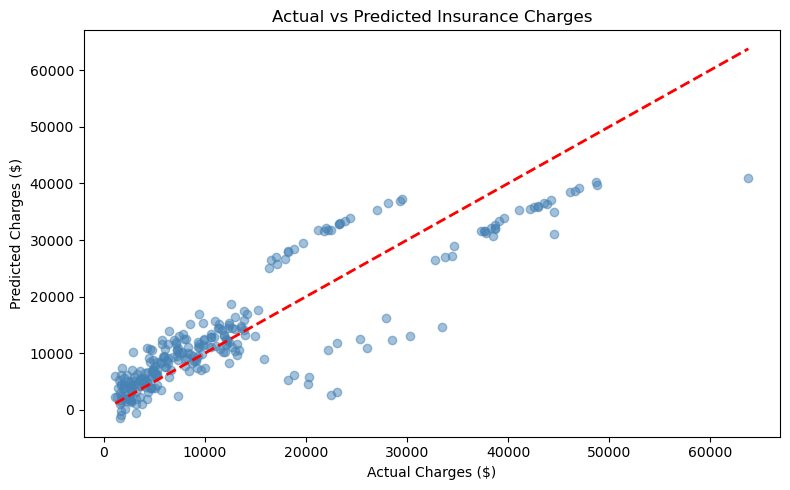

Points closer to the red line = better predictions!


In [16]:
# ================================================
# Visualization: Actual vs Predicted Charges
# Shows how close our predictions are to real values
# Perfect model would show all points on diagonal line
# ================================================

plt.figure(figsize=(8, 5))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,                     # X axis: actual charges
    y_pred,                     # Y axis: predicted charges
    alpha=0.5,                  # Transparency
    color='steelblue'           # Point color
)

# Draw perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',                      # Red dashed line
    linewidth=2
)

plt.title('Actual vs Predicted Insurance Charges')  # Title
plt.xlabel('Actual Charges ($)')                     # X axis label
plt.ylabel('Predicted Charges ($)')                  # Y axis label
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')               # Save the plot
plt.show()

print("Points closer to the red line = better predictions!")

## 7. Conclusion and Key Insights

The Linear Regression model was successfully trained to predict 
medical insurance charges based on personal and lifestyle data.

## Key findings from the analysis:

Smoking status is the most powerful predictor of insurance charges. 
Smokers pay on average 3 to 4 times more than non-smokers regardless 
of their age or BMI. This makes smoking the single biggest risk factor 
for high insurance costs.

Age has a positive relationship with insurance charges meaning older 
customers tend to pay more. This is expected as older people generally 
require more medical attention.

BMI also influences charges especially when combined with smoking. 
Customers who are both obese and smokers have the highest insurance 
charges in the dataset.

The correlation heatmap confirmed that smoking status, age, and BMI 
are the three most important features for predicting insurance charges.

The model achieved reasonable MAE and RMSE scores for a Linear 
Regression baseline model. More advanced models like Random Forest 
or Gradient Boosting could be used in future work to improve 
prediction accuracy further.

Overall this task demonstrates how personal lifestyle choices 
especially smoking have a dramatic impact on medical insurance costs.